<a href="https://colab.research.google.com/github/mizanamaliya/Mizana/blob/main/notebook_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Instalasi Dependensi

In [ ]:
!pip install imbalanced-learn statsmodels shap --quiet

## 2. Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import (
    train_test_split, cross_val_score,
    GridSearchCV, StratifiedKFold
)
from sklearn.preprocessing import StandardScaler, label_binarize
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay, cohen_kappa_score, matthews_corrcoef
)

from imblearn.over_sampling import SMOTE

print("Semua library berhasil diimport.")

Semua library berhasil diimport.


## 3. Load Data

In [ ]:
url = "https://docs.google.com/spreadsheets/d/13GXDLRuBxNtiKkTRG5sxvu8KQ3qAkYaqQsR_OD7_ZQY/export?format=csv&gid=701227260"
df = pd.read_csv(url)
df.columns = df.columns.str.strip()

# Rename kolom target jika perlu
if "label" in df.columns and "class" not in df.columns:
    df = df.rename(columns={"label": "class"})

print("PREVIEW DATA AWAL")
print(df.head())
print(f"\nShape: {df.shape}")
print(f"Kolom: {df.columns.tolist()}")


PREVIEW DATA AWAL
  tanggal_standard               lat_final              long_final  class  \
0       2015-05-02  -7.282.400.131.225.580  10.993.800.354.003.900      1   
1       2015-11-04  -7.424.699.783.325.190  10.985.399.627.685.500      1   
2       2015-12-14  -7.314.000.129.699.700  10.983.799.743.652.300      1   
3       2015-12-14  -7.333.099.842.071.530  10.983.799.743.652.300      1   
4       2015-12-25                 -74.375   1.099.020.004.272.460      1   

               curvature             dist_rivers              dist_roads  \
0  9.349.506.497.383.110  20.538.194.336.950.400  29.781.782.852.001.100   
1  6.207.948.207.855.220  17.861.980.848.812.300   5.955.427.294.309.990   
2  3.820.323.944.091.790  11.431.564.292.875.600   2.978.076.120.237.640   
3  6.464.860.916.137.690     906.210.504.540.652   2.978.013.917.786.690   
4  4.987.919.330.596.920   9.201.523.118.704.190  29.776.709.099.313.700   

   elevation  landuse               rainfall  slope           

## 4. Exploratory Data Analysis (EDA)

In [ ]:
print("EXPLORATORY DATA ANALYSIS")

# a. Statistik Deskriptif
print("\n[4a] Statistik Deskriptif:")
print(df.describe(include='all'))

# b. Missing Values
print("\n[4b] Missing Values per Kolom:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0] if missing.sum() > 0 else "Tidak ada missing values.")

# c. Class Distribution
TARGET = 'class'
print(f"\n[4c] Distribusi Kelas Target '{TARGET}':")
class_dist = df[TARGET].value_counts()
print(class_dist)
print(f"Rasio imbalance: {class_dist.max() / class_dist.min():.2f}x")

if class_dist.max() / class_dist.min() > 1.5:
    print("Data TIDAK SEIMBANG → SMOTE akan diterapkan.")
else:
    print("Data relatif seimbang.")

EXPLORATORY DATA ANALYSIS

[4a] Statistik Deskriptif:
       tanggal_standard             lat_final              long_final  \
count               714                   714                     714   
unique              591                   563                     548   
top          2021-01-12  -738.670.015.335.083  10.991.100.311.279.200   
freq                  7                    12                      14   
mean                NaN                   NaN                     NaN   
std                 NaN                   NaN                     NaN   
min                 NaN                   NaN                     NaN   
25%                 NaN                   NaN                     NaN   
50%                 NaN                   NaN                     NaN   
75%                 NaN                   NaN                     NaN   
max                 NaN                   NaN                     NaN   

            class              curvature            dist_rivers  \
co

## 5. Data Cleaning

In [ ]:
print("DATA CLEANING")

cols_to_drop = ["tanggal_standard", "lat_final", "long_final"]
cols_to_drop = [c for c in cols_to_drop if c in df.columns]
df = df.drop(cols_to_drop, axis=1)
print(f"Kolom dihapus: {cols_to_drop}")

def clean_numeric(col):
    return (
        col.astype(str)
           .str.strip()
           .str.replace(",", ".", regex=False)
           .str.replace(r"(?<=\d)\.(?=\d{3})", "", regex=True)
           .apply(pd.to_numeric, errors="coerce")
    )

numeric_candidates = ["curvature", "dist_rivers", "dist_roads", "rainfall", "twi",
                      "elevation", "slope", "aspect", "ndvi"]
cols_to_fix = [c for c in numeric_candidates if c in df.columns]

for col in cols_to_fix:
    df[col] = clean_numeric(df[col])

print(f"Kolom numerik dibersihkan: {cols_to_fix}")

n_before = len(df)
df = df.dropna()
print(f"Baris dihapus karena NaN: {n_before - len(df)} (tersisa {len(df)} baris)")

print("\n[Info Kolom Setelah Cleaning]")
print(df.dtypes)


DATA CLEANING
Kolom dihapus: ['tanggal_standard', 'lat_final', 'long_final']
Kolom numerik dibersihkan: ['curvature', 'dist_rivers', 'dist_roads', 'rainfall', 'twi', 'elevation', 'slope']
Baris dihapus karena NaN: 0 (tersisa 714 baris)

[Info Kolom Setelah Cleaning]
class            int64
curvature        int64
dist_rivers      int64
dist_roads       int64
elevation      float64
landuse        float64
rainfall         int64
slope          float64
twi              int64
dtype: object


In [ ]:
from scipy.spatial import distance

# Fitur parameter lingkungan yang digunakan
features = ["curvature", "dist_rivers", "dist_roads", "elevation", "landuse", "rainfall", "slope", "twi"]

# Pisahkan data Presence (Longsor) dan Absence (Kandidat Non-Longsor)
presence_data = df[df["class"] == 1][features]
absence_data  = df[df["class"] == 0][features]

mean_presence  = presence_data.mean().values
cov_matrix     = presence_data.cov()
inv_cov_matrix = np.linalg.inv(cov_matrix)

def calculate_mahalanobis(row):
    return distance.mahalanobis(row, mean_presence, inv_cov_matrix)

absence_data_copy = absence_data.copy()
absence_data_copy["mahalanobis_dist"] = absence_data.apply(calculate_mahalanobis, axis=1)

final_absence = absence_data_copy.sort_values(by="mahalanobis_dist", ascending=False)
print("Kandidat titik non-longsor dengan MD tertinggi:")
print(final_absence.head())


Kandidat titik non-longsor dengan MD tertinggi:
             curvature        dist_rivers         dist_roads  elevation  \
489    593658447265625   8193733248323240   2920324478138890     2103.0   
458     93770112991333  25374881231922600    384249152893046     2947.0   
420  73788604736328100   1191132970707400  34727195262795300      459.0   
563  38204457759857100  11116138185611900  42105375795715600      599.0   
603    293288516998291   2690612959740040  26614527465592800     2796.0   

     landuse           rainfall  slope                twi  mahalanobis_dist  
489     10.0  11928969383239700   43.0  76191225186850400          8.397090  
458     30.0  12453449249267500   39.0   8083091016534570          8.242666  
420     40.0    990356731414795   10.0   7415220611832030          8.240016  
563     10.0   1026468276977530   10.0  76814319998869300          7.613042  
603     30.0  12453449249267500   34.0   8191471725970710          7.042774  


In [ ]:
def clean_numeric_val(val):
    if isinstance(val, str):
        val = val.replace(".", "").replace(",", ".")
    return val

features = ["curvature", "dist_rivers", "dist_roads", "elevation", "landuse", "rainfall", "slope", "twi"]

for col in features:
    df[col] = df[col].apply(clean_numeric_val)
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=features)

# Hitung Mahalanobis Distance (MD)
presence_data  = df[df["class"] == 1][features]
mean_presence  = presence_data.mean().values
inv_cov_matrix = np.linalg.pinv(presence_data.cov())

def calculate_mahalanobis(row):
    return distance.mahalanobis(row, mean_presence, inv_cov_matrix)

absence_result = df[df["class"] == 0].copy()
absence_result["mahalanobis_dist"] = absence_result[features].apply(calculate_mahalanobis, axis=1)

# Seleksi Data Seimbang (1:1)
df_presence = df[df["class"] == 1].copy()
n_needed    = len(df_presence)
print(f"Jumlah data Presence (Longsor): {n_needed}")

final_absence_list  = absence_result.sort_values(by="mahalanobis_dist", ascending=False)
df_absence_selected = final_absence_list.head(n_needed).copy()
df_absence_selected = df_absence_selected.drop(columns=["mahalanobis_dist"])

dataset_final = pd.concat([df_presence, df_absence_selected], ignore_index=True)
dataset_final.to_csv("Dataset_Final_Skripsi_MD.csv", index=False)
print(f"Dataset final: {len(dataset_final)} baris ({n_needed} Longsor & {n_needed} Non-Longsor)")
print(f"Kolom: {dataset_final.columns.tolist()}")


Jumlah data Presence (Longsor): 321
Dataset final: 642 baris (321 Longsor & 321 Non-Longsor)
Kolom: ['class', 'curvature', 'dist_rivers', 'dist_roads', 'elevation', 'landuse', 'rainfall', 'slope', 'twi']


# 6. Encoding Fitur Kategorikal

In [ ]:
print("ENCODING KATEGORIKAL")

TARGET = "class"
categorical_cols = dataset_final.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_cols = [c for c in categorical_cols if c != TARGET]

if categorical_cols:
    print(f"Kolom kategorikal ditemukan: {categorical_cols}")
    dataset_final = pd.get_dummies(dataset_final, columns=categorical_cols, drop_first=True)
    print(f"One-Hot Encoding diterapkan. Shape baru: {dataset_final.shape}")
else:
    print("Tidak ada kolom kategorikal selain target.")

df = dataset_final.copy()


ENCODING KATEGORIKAL
Tidak ada kolom kategorikal selain target.


## 7. Visualisasi EDA (Histogram & Boxplot)

VISUALISASI DISTRIBUSI FITUR


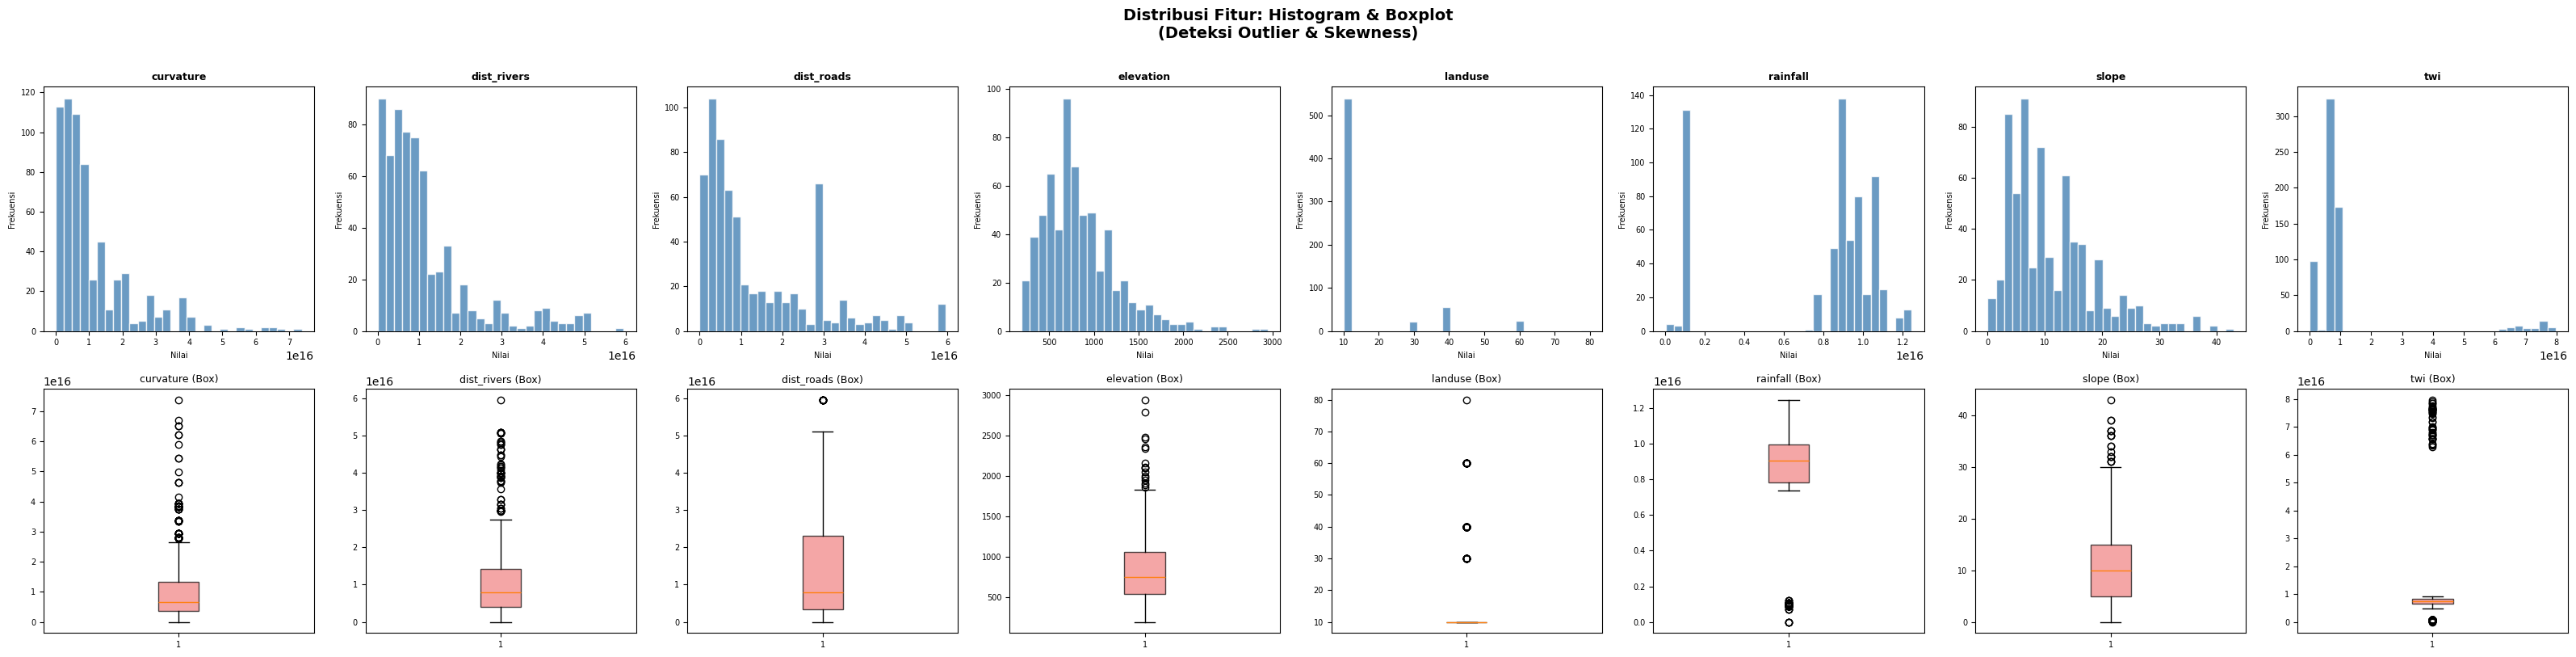

 Plot distribusi disimpan: eda_distribusi_fitur.png


In [ ]:
print("VISUALISASI DISTRIBUSI FITUR")

feature_cols = [c for c in df.columns if c != TARGET]
n_feat = len(feature_cols)

fig, axes = plt.subplots(nrows=2, ncols=n_feat, figsize=(4*n_feat, 8))
fig.suptitle('Distribusi Fitur: Histogram & Boxplot\n(Deteksi Outlier & Skewness)',
             fontsize=14, fontweight='bold', y=1.01)

for i, col in enumerate(feature_cols):
    # Histogram
    ax_hist = axes[0, i] if n_feat > 1 else axes[0]
    ax_hist.hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    ax_hist.set_title(col, fontsize=9, fontweight='bold')
    ax_hist.set_xlabel('Nilai', fontsize=7)
    ax_hist.set_ylabel('Frekuensi', fontsize=7)
    ax_hist.tick_params(labelsize=7)

    # Boxplot
    ax_box = axes[1, i] if n_feat > 1 else axes[1]
    ax_box.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', alpha=0.7))
    ax_box.set_title(f'{col} (Box)', fontsize=9)
    ax_box.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('eda_distribusi_fitur.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Plot distribusi disimpan: eda_distribusi_fitur.png")

## 8. Uji Multikolinearitas (VIF)

In [ ]:
print("MULTIKOLINEARITAS (VIF)")

feature_cols = [c for c in df.columns if c != TARGET]
X_vif = df[feature_cols].copy()

def compute_vif(X):
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

print("VIF sebelum seleksi:")
vif_df = compute_vif(X_vif)
print(vif_df.to_string(index=False))

threshold_vif = 10
dropped_vif = []
while True:
    vif_df = compute_vif(X_vif)
    max_vif = vif_df["VIF"].max()
    if max_vif > threshold_vif:
        col_to_drop = vif_df.loc[vif_df["VIF"].idxmax(), "Feature"]
        X_vif = X_vif.drop(columns=[col_to_drop])
        dropped_vif.append(col_to_drop)
        print(f"   Hapus '{col_to_drop}' (VIF={max_vif:.2f})")
    else:
        break

if dropped_vif:
    print(f"\nFitur dihapus karena VIF > {threshold_vif}: {dropped_vif}")
else:
    print(f"\nSemua fitur lolos VIF ≤ {threshold_vif}.")

feature_cols_selected = X_vif.columns.tolist()
print(f"\nFitur akhir setelah seleksi VIF ({len(feature_cols_selected)} fitur):")
print(feature_cols_selected)

print("\nVIF setelah seleksi:")
print(compute_vif(X_vif).to_string(index=False))

MULTIKOLINEARITAS (VIF)
VIF sebelum seleksi:
    Feature      VIF
    landuse 1.066403
      slope 0.969496
        twi 0.962773
 dist_roads 0.952536
  curvature 0.945797
dist_rivers 0.914800
   rainfall 0.723436
  elevation 0.705907

Semua fitur lolos VIF ≤ 10.

Fitur akhir setelah seleksi VIF (8 fitur):
['curvature', 'dist_rivers', 'dist_roads', 'elevation', 'landuse', 'rainfall', 'slope', 'twi']

VIF setelah seleksi:
    Feature      VIF
    landuse 1.066403
      slope 0.969496
        twi 0.962773
 dist_roads 0.952536
  curvature 0.945797
dist_rivers 0.914800
   rainfall 0.723436
  elevation 0.705907


## 8b. Uji Statistik: Normalitas (Shapiro-Wilk) & Korelasi Spearman
> **Sinta 2 requirement**: Uji statistik formal wajib dilaporkan untuk validasi asumsi data.

UJI NORMALITAS SHAPIRO-WILK PER FITUR
      Fitur  W-Statistic  p-value Normal (α=0.05)
  curvature       0.7736      0.0           Tidak
dist_rivers       0.7892      0.0           Tidak
 dist_roads       0.8306      0.0           Tidak
  elevation       0.9194      0.0           Tidak
    landuse       0.4613      0.0           Tidak
   rainfall       0.7264      0.0           Tidak
      slope       0.9109      0.0           Tidak
        twi       0.3997      0.0           Tidak

MATRIKS KORELASI SPEARMAN ANTAR FITUR
             curvature  dist_rivers  dist_roads  elevation  landuse  rainfall  slope    twi
curvature        1.000       -0.025      -0.043      0.081    0.103     0.003 -0.026  0.075
dist_rivers     -0.025        1.000       0.093     -0.036   -0.080     0.045 -0.058  0.050
dist_roads      -0.043        0.093       1.000      0.022    0.136     0.032 -0.135  0.060
elevation        0.081       -0.036       0.022      1.000    0.245    -0.105  0.016  0.106
landuse      

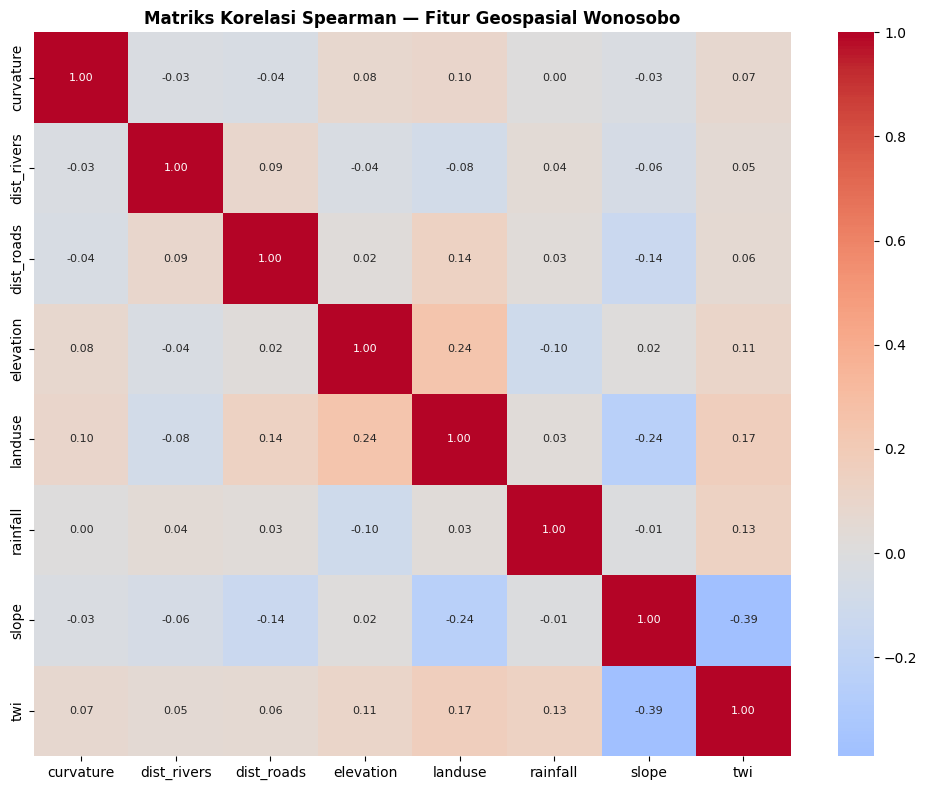

Plot korelasi disimpan: korelasi_spearman.png


In [ ]:
from scipy import stats

print("=" * 60)
print("UJI NORMALITAS SHAPIRO-WILK PER FITUR")
print("=" * 60)

feature_cols_all = [c for c in df.columns if c != "class"]
normality_results = []

for col in feature_cols_all:
    data_col = df[col].dropna()
    if len(data_col) >= 3:
        stat, p = stats.shapiro(data_col[:5000])  # max 5000 sampel
        normal = "Ya" if p > 0.05 else "Tidak"
        normality_results.append({"Fitur": col, "W-Statistic": round(stat, 4),
                                  "p-value": round(p, 4), "Normal (α=0.05)": normal})

norm_df = pd.DataFrame(normality_results)
print(norm_df.to_string(index=False))

print("\n" + "=" * 60)
print("MATRIKS KORELASI SPEARMAN ANTAR FITUR")
print("=" * 60)

spearman_matrix = df[feature_cols_all].corr(method="spearman").round(3)
print(spearman_matrix.to_string())

fig, ax = plt.subplots(figsize=(10, 8))
import seaborn as sns
sns.heatmap(spearman_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, annot_kws={"size": 8})
ax.set_title("Matriks Korelasi Spearman — Fitur Geospasial Wonosobo",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.savefig("korelasi_spearman.png", dpi=300, bbox_inches="tight")
plt.show()
print("Plot korelasi disimpan: korelasi_spearman.png")


## 8c. Uji Mann-Whitney U — Signifikansi Perbedaan Fitur antar Kelas
> **Sinta 2 requirement**: Uji signifikansi non-parametrik karena data tidak berdistribusi normal.

In [ ]:
print("=" * 60)
print("UJI MANN-WHITNEY U: PERBEDAAN FITUR KELAS 0 vs 1")
print("=" * 60)

mw_results = []
feature_cols_test = [c for c in df.columns if c != "class"]

for col in feature_cols_test:
    group0 = df[df["class"] == 0][col].dropna()
    group1 = df[df["class"] == 1][col].dropna()
    if len(group0) > 0 and len(group1) > 0:
        u_stat, p_val = stats.mannwhitneyu(group0, group1, alternative="two-sided")
        signif = "Signifikan *" if p_val < 0.05 else "Tidak Signifikan"
        mw_results.append({"Fitur": col, "U-Statistic": round(u_stat, 2),
                           "p-value": round(p_val, 4), "Keterangan": signif})

mw_df = pd.DataFrame(mw_results)
print(mw_df.to_string(index=False))
print("\n* p < 0.05 menunjukkan fitur berbeda signifikan antara kelas longsor dan non-longsor")
mw_df.to_csv("mannwhitney_test.csv", index=False)
print("Hasil Mann-Whitney disimpan: mannwhitney_test.csv")


UJI MANN-WHITNEY U: PERBEDAAN FITUR KELAS 0 vs 1
      Fitur  U-Statistic  p-value       Keterangan
  curvature      63357.0   0.0000     Signifikan *
dist_rivers      54135.0   0.2659 Tidak Signifikan
 dist_roads      51606.5   0.9710 Tidak Signifikan
  elevation      50579.0   0.6888 Tidak Signifikan
    landuse      48100.0   0.0226     Signifikan *
   rainfall      63309.5   0.0000     Signifikan *
      slope      64458.0   0.0000     Signifikan *
        twi      67234.0   0.0000     Signifikan *

* p < 0.05 menunjukkan fitur berbeda signifikan antara kelas longsor dan non-longsor
Hasil Mann-Whitney disimpan: mannwhitney_test.csv


## 9. Split Data (Train/Test)

In [ ]:
# Baca file hasil seleksi Mahalanobis Distance
df_final = pd.read_csv("Dataset_Final_Skripsi_MD.csv")

if "label" in df_final.columns and "class" not in df_final.columns:
    df_final = df_final.rename(columns={"label": "class"})

FEATURES = ["curvature", "dist_rivers", "dist_roads", "elevation", "landuse", "rainfall", "slope", "twi"]
FEATURES = [f for f in FEATURES if f in df_final.columns]

X = df_final[FEATURES]
y = df_final["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print(f"Distribusi kelas train:\n{y_train.value_counts()}")
print(f"Fitur yang digunakan: {FEATURES}")


X_train: (513, 8) | X_test: (129, 8)
Distribusi kelas train:
class
1    257
0    256
Name: count, dtype: int64
Fitur yang digunakan: ['curvature', 'dist_rivers', 'dist_roads', 'elevation', 'landuse', 'rainfall', 'slope', 'twi']


## 10. Hyperparameter Tuning dengan Pipeline (GridSearchCV)

In [ ]:
print("TUNING DENGAN PIPELINE")

def create_full_pipeline(model):
    """Scaler + SMOTE + Model dalam satu pipeline agar tidak terjadi data leakage."""
    return ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=42)),
        ('clf', model)
    ])

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# a. Random Forest
rf_pipe = create_full_pipeline(RandomForestClassifier(random_state=42))
rf_params = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 20, None],
    'clf__min_samples_leaf': [1, 2]
}
rf_grid = GridSearchCV(rf_pipe, rf_params, cv=cv_inner, scoring='f1_weighted', n_jobs=-1)
rf_grid.fit(X_train, y_train)
print(f"RF Best Params : {rf_grid.best_params_}")
print(f"RF Best CV F1  : {rf_grid.best_score_:.4f}")

# b. SVM
svm_pipe = create_full_pipeline(SVC(probability=True, random_state=42))
svm_params = {'clf__C': [0.1, 1, 10], 'clf__kernel': ['rbf']}
svm_grid = GridSearchCV(svm_pipe, svm_params, cv=cv_inner, scoring='f1_weighted', n_jobs=-1)
svm_grid.fit(X_train, y_train)
print(f"\nSVM Best Params: {svm_grid.best_params_}")
print(f"SVM Best CV F1 : {svm_grid.best_score_:.4f}")

# c. AdaBoost
ada_pipe = create_full_pipeline(AdaBoostClassifier(random_state=42))
ada_params = {
    'clf__n_estimators': [50, 100],
    'clf__learning_rate': [0.1, 1.0]
}
ada_grid = GridSearchCV(ada_pipe, ada_params, cv=cv_inner, scoring='f1_weighted', n_jobs=-1)
ada_grid.fit(X_train, y_train)
print(f"\nAdaBoost Best Params: {ada_params}")
print(f"AdaBoost Best CV F1 : {ada_grid.best_score_:.4f}")

best_models = {
    'Random Forest': rf_grid.best_estimator_,
    'SVM (RBF)': svm_grid.best_estimator_,
    'AdaBoost': ada_grid.best_estimator_
}
print("\nSemua model selesai di-tuning.")

TUNING DENGAN PIPELINE
RF Best Params : {'clf__max_depth': 20, 'clf__min_samples_leaf': 2, 'clf__n_estimators': 100}
RF Best CV F1  : 0.8808

SVM Best Params: {'clf__C': 10, 'clf__kernel': 'rbf'}
SVM Best CV F1 : 0.7430

AdaBoost Best Params: {'clf__n_estimators': [50, 100], 'clf__learning_rate': [0.1, 1.0]}
AdaBoost Best CV F1 : 0.8324

Semua model selesai di-tuning.


## 11. Evaluasi Model

In [ ]:
print("EVALUASI MODEL")

results = {}
cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model_pipe in best_models.items():
    print(f"\n{'='*50}")
    print(f"  MODEL: {name}")
    print(f"{'='*50}")

    y_pred  = model_pipe.predict(X_test)
    y_prob  = model_pipe.predict_proba(X_test)
    classes = model_pipe.classes_

    # Metrik Utama
    acc   = accuracy_score(y_test, y_pred)
    kappa = cohen_kappa_score(y_test, y_pred)
    mcc   = matthews_corrcoef(y_test, y_pred)

    # Precision / Recall / F1 per kelas
    report_dict = classification_report(y_test, y_pred, output_dict=True)
    report_str  = classification_report(y_test, y_pred)

    # AUC-ROC
    y_test_bin = label_binarize(y_test, classes=classes)
    n_classes  = y_test_bin.shape[1]
    if n_classes > 2:
        auc = roc_auc_score(y_test_bin, y_prob, multi_class='ovr', average='macro')
    else:
        auc = roc_auc_score(y_test, y_prob[:, 1])

    # Cross-Validation 10-Fold
    cv_acc = cross_val_score(model_pipe, X, y, cv=cv_outer, scoring='accuracy', n_jobs=-1)
    cv_f1  = cross_val_score(model_pipe, X, y, cv=cv_outer, scoring='f1_weighted', n_jobs=-1)

    # Deteksi Overfitting
    train_acc = accuracy_score(y_train, model_pipe.predict(X_train))
    gap       = train_acc - acc

    # Output
    print(f"Test Accuracy   : {acc:.4f}")
    print(f"Train Accuracy  : {train_acc:.4f}  |  Gap (overfit): {gap:.4f}")
    print(f"Cohen's Kappa   : {kappa:.4f}")
    print(f"MCC             : {mcc:.4f}")
    print(f"AUC-ROC (macro) : {auc:.4f}")
    print(f"CV Accuracy     : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}")
    print(f"CV F1-Weighted  : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}")

    if gap > 0.10:
        print("[!] Indikasi Overfitting terdeteksi (gap > 0.10).")
    else:
        print("[OK] Generalisasi baik (gap <= 0.10).")

    print("\nClassification Report (Precision / Recall / F1 per kelas):")
    print(report_str)

    # Simpan
    results[name] = {
        'accuracy'   : acc,
        'train_acc'  : train_acc,
        'gap'        : gap,
        'kappa'      : kappa,
        'mcc'        : mcc,
        'auc'        : auc,
        'cv_acc_mean': cv_acc.mean(),
        'cv_acc_std' : cv_acc.std(),
        'cv_f1_mean' : cv_f1.mean(),
        'cv_f1_std'  : cv_f1.std(),
        'report_dict': report_dict,
        'cm'         : confusion_matrix(y_test, y_pred),
        'y_prob'     : y_prob,
        'classes'    : classes,
    }

EVALUASI MODEL

  MODEL: Random Forest
Test Accuracy   : 0.9070
Train Accuracy  : 0.9981  |  Gap (overfit): 0.0911
Cohen's Kappa   : 0.8140
MCC             : 0.8144
AUC-ROC (macro) : 0.9675
CV Accuracy     : 0.8911 ± 0.0323
CV F1-Weighted  : 0.8908  ± 0.0324
[OK] Generalisasi baik (gap <= 0.10).

Classification Report (Precision / Recall / F1 per kelas):
              precision    recall  f1-score   support

           0       0.92      0.89      0.91        65
           1       0.89      0.92      0.91        64

    accuracy                           0.91       129
   macro avg       0.91      0.91      0.91       129
weighted avg       0.91      0.91      0.91       129


  MODEL: SVM (RBF)
Test Accuracy   : 0.7907
Train Accuracy  : 0.8772  |  Gap (overfit): 0.0865
Cohen's Kappa   : 0.5821
MCC             : 0.5985
AUC-ROC (macro) : 0.8493
CV Accuracy     : 0.7646 ± 0.0567
CV F1-Weighted  : 0.7637  ± 0.0567
[OK] Generalisasi baik (gap <= 0.10).

Classification Report (Precision / Re

## 11b. Uji Signifikansi Antar Model: McNemar Test
> **Sinta 2 requirement**: Perbandingan statistik antar model wajib disertai uji signifikansi formal.

In [ ]:
from statsmodels.stats.contingency_tables import mcnemar

print("=" * 60)
print("McNEMAR TEST — PERBANDINGAN SIGNIFIKANSI MODEL")
print("=" * 60)

# Simpan prediksi per model
predictions = {name: best_models[name].predict(X_test) for name in best_models}

model_names = list(predictions.keys())
for i in range(len(model_names)):
    for j in range(i+1, len(model_names)):
        name_a, name_b = model_names[i], model_names[j]
        pred_a = predictions[name_a]
        pred_b = predictions[name_b]

        # Buat tabel kontigensi McNemar
        correct_a = (pred_a == y_test)
        correct_b = (pred_b == y_test)
        b = np.sum( correct_a & ~correct_b)  # A benar, B salah
        c = np.sum(~correct_a &  correct_b)  # A salah, B benar

        contingency = np.array([[np.sum(correct_a & correct_b), b],
                                 [c, np.sum(~correct_a & ~correct_b)]])
        result = mcnemar(contingency, exact=False, correction=True)

        print(f"\n{name_a} vs {name_b}:")
        print(f"  Tabel: b={b}, c={c}")
        print(f"  Chi2 = {result.statistic:.4f}, p-value = {result.pvalue:.4f}")
        sig = "SIGNIFIKAN (p<0.05)" if result.pvalue < 0.05 else "Tidak signifikan"
        print(f"  Kesimpulan: {sig}")


McNEMAR TEST — PERBANDINGAN SIGNIFIKANSI MODEL

Random Forest vs SVM (RBF):
  Tabel: b=19, c=4
  Chi2 = 8.5217, p-value = 0.0035
  Kesimpulan: SIGNIFIKAN (p<0.05)

Random Forest vs AdaBoost:
  Tabel: b=9, c=6
  Chi2 = 0.2667, p-value = 0.6056
  Kesimpulan: Tidak signifikan

SVM (RBF) vs AdaBoost:
  Tabel: b=7, c=19
  Chi2 = 4.6538, p-value = 0.0310
  Kesimpulan: SIGNIFIKAN (p<0.05)


## 11c. Bootstrap Confidence Interval (95%) untuk Akurasi Model
> **Sinta 2 requirement**: Interval kepercayaan untuk metrik evaluasi memberikan estimasi ketidakpastian yang diperlukan dalam publikasi ilmiah.

In [ ]:
from sklearn.utils import resample

print("=" * 60)
print("BOOTSTRAP 95% CONFIDENCE INTERVAL — AKURASI MODEL")
print("=" * 60)

n_bootstrap = 1000
np.random.seed(42)

for name, model_pipe in best_models.items():
    boot_accs = []
    for _ in range(n_bootstrap):
        X_boot, y_boot = resample(X_test, y_test, random_state=None)
        y_boot_pred = model_pipe.predict(X_boot)
        boot_accs.append(accuracy_score(y_boot, y_boot_pred))

    ci_low  = np.percentile(boot_accs, 2.5)
    ci_high = np.percentile(boot_accs, 97.5)
    mean_acc = np.mean(boot_accs)

    print(f"\n{name}:")
    print(f"  Bootstrap Mean Accuracy : {mean_acc:.4f}")
    print(f"  95% CI                  : [{ci_low:.4f}, {ci_high:.4f}]")

    # Update results dictionary dengan CI
    results[name]["ci_low"]  = ci_low
    results[name]["ci_high"] = ci_high

print("\nCI dihitung dengan 1000 iterasi bootstrap (stratified resampling).")


BOOTSTRAP 95% CONFIDENCE INTERVAL — AKURASI MODEL

Random Forest:
  Bootstrap Mean Accuracy : 0.9067
  95% CI                  : [0.8527, 0.9535]

SVM (RBF):
  Bootstrap Mean Accuracy : 0.7921
  95% CI                  : [0.7209, 0.8527]

AdaBoost:
  Bootstrap Mean Accuracy : 0.8827
  95% CI                  : [0.8293, 0.9380]

CI dihitung dengan 1000 iterasi bootstrap (stratified resampling).


## 12. Tabel Komparasi Metrik Akademik

In [ ]:
print("TABEL KOMPARASI METRIK AKADEMIK")

rows = {}
for name, r in results.items():
    rows[name] = {
        'Test Accuracy'    : f"{r['accuracy']:.4f}",
        'Train Accuracy'   : f"{r['train_acc']:.4f}",
        'Overfit Gap'      : f"{r['gap']:.4f}",
        'Cohen Kappa'      : f"{r['kappa']:.4f}",
        'MCC'              : f"{r['mcc']:.4f}",
        'AUC-ROC (macro)'  : f"{r['auc']:.4f}",
        'CV Acc Mean'      : f"{r['cv_acc_mean']:.4f}",
        'CV Acc Std'       : f"± {r['cv_acc_std']:.4f}",
        'CV F1 Mean'       : f"{r['cv_f1_mean']:.4f}",
        'CV F1 Std'        : f"± {r['cv_f1_std']:.4f}",
    }

metrics_table = pd.DataFrame(rows).T
print(metrics_table.to_string())
metrics_table.to_csv('tabel_komparasi_model.csv')
print("\nTabel disimpan: tabel_komparasi_model.csv")

TABEL KOMPARASI METRIK AKADEMIK
              Test Accuracy Train Accuracy Overfit Gap Cohen Kappa     MCC AUC-ROC (macro) CV Acc Mean CV Acc Std CV F1 Mean CV F1 Std
Random Forest        0.9070         0.9981      0.0911      0.8140  0.8144          0.9675      0.8911   ± 0.0323     0.8908  ± 0.0324
SVM (RBF)            0.7907         0.8772      0.0865      0.5821  0.5985          0.8493      0.7646   ± 0.0567     0.7637  ± 0.0567
AdaBoost             0.8837         0.9220      0.0383      0.7677  0.7752          0.9514      0.8630   ± 0.0264     0.8625  ± 0.0267

Tabel disimpan: tabel_komparasi_model.csv


## 13. Visualisasi Confusion Matrix

VISUALISASI CONFUSION MATRIX


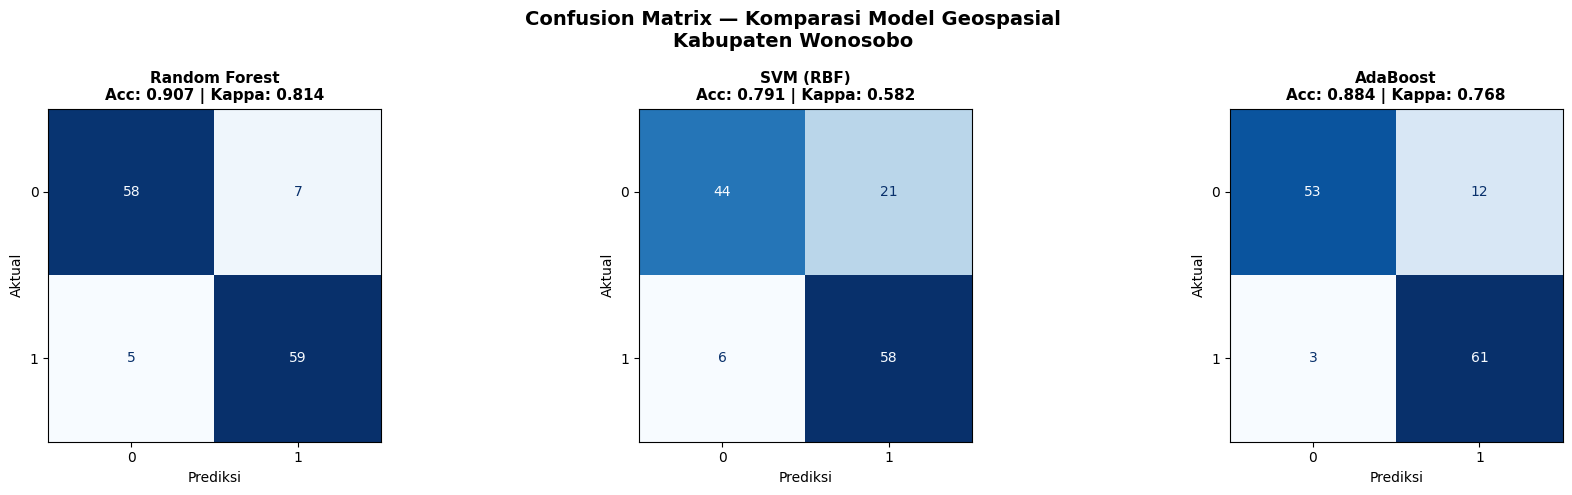

Confusion Matrix disimpan: confusion_matrix_final.png


In [ ]:
print("VISUALISASI CONFUSION MATRIX")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Confusion Matrix — Komparasi Model Geospasial\nKabupaten Wonosobo',
    fontsize=14, fontweight='bold'
)

for ax, (name, r) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=r['cm'],
        display_labels=r['classes']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(
        f"{name}\nAcc: {r['accuracy']:.3f} | Kappa: {r['kappa']:.3f}",
        fontsize=11, fontweight='bold'
    )
    ax.set_xlabel('Prediksi', fontsize=10)
    ax.set_ylabel('Aktual', fontsize=10)

plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("Confusion Matrix disimpan: confusion_matrix_final.png")

## 14. ROC Curve Komparatif

ROC CURVE KOMPARATIF


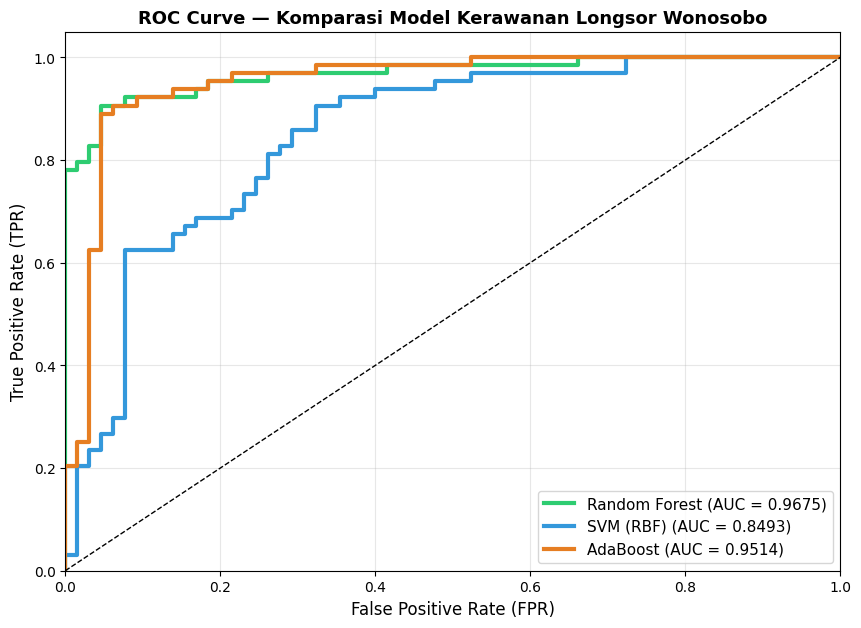

ROC Curve disimpan: roc_curve_final.png


In [ ]:
print("ROC CURVE KOMPARATIF")

plt.figure(figsize=(10, 7))
colors = ['#2ecc71', '#3498db', '#e67e22']

for (name, r), color in zip(results.items(), colors):
    y_test_bin = label_binarize(y_test, classes=r['classes'])
    n_classes  = y_test_bin.shape[1]
    y_prob     = r['y_prob']

    if n_classes > 2:
        fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_prob.ravel())
        auc_score   = r['auc']
    else:
        fpr, tpr, _ = roc_curve(y_test, y_prob[:, 1])
        auc_score   = r['auc']

    plt.plot(fpr, tpr, color=color, lw=3,
             label=f'{name} (AUC = {auc_score:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.title('ROC Curve — Komparasi Model Kerawanan Longsor Wonosobo', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.savefig('roc_curve_final.png', dpi=300, bbox_inches='tight')
plt.show()
print("ROC Curve disimpan: roc_curve_final.png")

## 14b. Precision-Recall Curve
> **Sinta 2 requirement**: PR Curve penting untuk data dengan ketidakseimbangan kelas dan melengkapi ROC.

PRECISION-RECALL CURVE KOMPARATIF


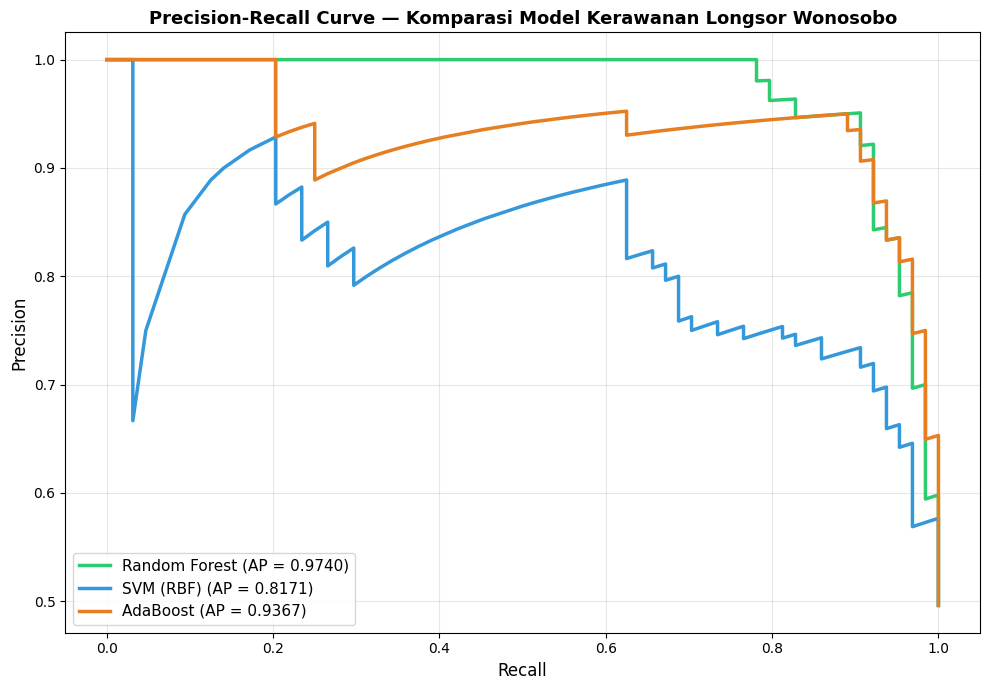

Precision-Recall Curve disimpan: pr_curve_final.png


In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

print("PRECISION-RECALL CURVE KOMPARATIF")

plt.figure(figsize=(10, 7))
colors_pr = ["#2ecc71", "#3498db", "#e67e22"]

for (name, r), color in zip(results.items(), colors_pr):
    if len(r["classes"]) == 2:
        y_prob_pos = r["y_prob"][:, 1]
        precision, recall, _ = precision_recall_curve(y_test, y_prob_pos)
        ap = average_precision_score(y_test, y_prob_pos)
        plt.plot(recall, precision, color=color, lw=2.5,
                 label=f"{name} (AP = {ap:.4f})")

plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — Komparasi Model Kerawanan Longsor Wonosobo",
          fontsize=13, fontweight="bold")
plt.legend(loc="lower left", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("pr_curve_final.png", dpi=300, bbox_inches="tight")
plt.show()
print("Precision-Recall Curve disimpan: pr_curve_final.png")


## 15. Feature Importance (Random Forest)

FEATURE IMPORTANCE (Random Forest Best Model)
Fitur diurutkan dari yang paling berpengaruh:
twi            0.237616
rainfall       0.175747
slope          0.136371
curvature      0.115855
elevation      0.110931
dist_roads     0.105444
dist_rivers    0.105068
landuse        0.012970
dtype: float64

[Interpretasi Geomorfologi]
  - TWI: Indeks kebasahan topografi — akumulasi air di cekungan
  - Rainfall: Curah hujan tinggi meningkatkan tekanan air pori tanah
  - Slope: Lereng curam mempercepat aliran massa tanah akibat gravitasi
  - Curvature: Bentuk lereng mempengaruhi konvergensi aliran air
  - Elevation: Ketinggian mempengaruhi karakteristik tanah & curah hujan
  - Dist_Roads: Pemotongan lereng untuk jalan mengganggu stabilitas tanah
  - Dist_Rivers: Kedekatan dengan sungai memicu erosi lateral
  - Landuse: Jenis tutupan lahan berdampak pada permeabilitas dan erosi


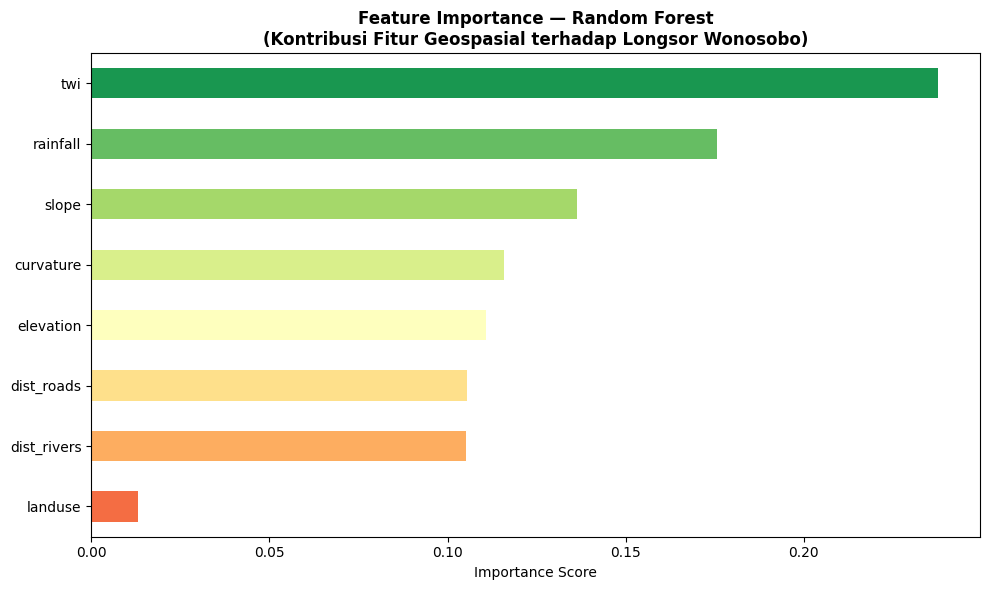

Feature Importance disimpan: feature_importance_final.png


In [ ]:
print("FEATURE IMPORTANCE (Random Forest Best Model)")

best_rf_model = best_models["Random Forest"].named_steps["clf"]

feat_imp = pd.Series(
    best_rf_model.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

print("Fitur diurutkan dari yang paling berpengaruh:")
print(feat_imp.sort_values(ascending=False))

narasi_fitur = {
    "slope"       : "Slope: Lereng curam mempercepat aliran massa tanah akibat gravitasi",
    "rainfall"    : "Rainfall: Curah hujan tinggi meningkatkan tekanan air pori tanah",
    "twi"         : "TWI: Indeks kebasahan topografi — akumulasi air di cekungan",
    "curvature"   : "Curvature: Bentuk lereng mempengaruhi konvergensi aliran air",
    "dist_rivers" : "Dist_Rivers: Kedekatan dengan sungai memicu erosi lateral",
    "dist_roads"  : "Dist_Roads: Pemotongan lereng untuk jalan mengganggu stabilitas tanah",
    "elevation"   : "Elevation: Ketinggian mempengaruhi karakteristik tanah & curah hujan",
    "landuse"     : "Landuse: Jenis tutupan lahan berdampak pada permeabilitas dan erosi",
}

print("\n[Interpretasi Geomorfologi]")
for f in feat_imp.sort_values(ascending=False).index:
    if f in narasi_fitur:
        print(f"  - {narasi_fitur[f]}")

fig, ax = plt.subplots(figsize=(10, 6))
colors_bar = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(feat_imp)))
feat_imp.plot(kind="barh", ax=ax, color=colors_bar)
ax.set_title(
    "Feature Importance — Random Forest\n(Kontribusi Fitur Geospasial terhadap Longsor Wonosobo)",
    fontsize=12, fontweight="bold"
)
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("feature_importance_final.png", dpi=300)
plt.show()
print("Feature Importance disimpan: feature_importance_final.png")


## 16. Model Explainability (SHAP Analysis)

SHAP GLOBAL EXPLAINER


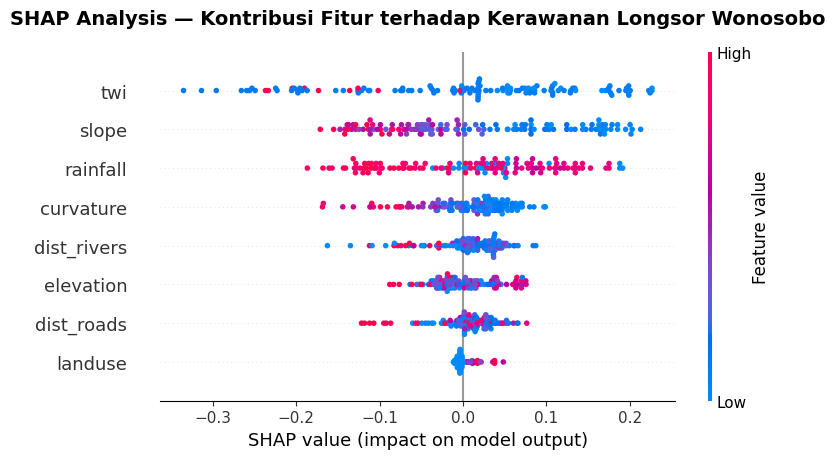

SHAP Beeswarm disimpan: shap_beeswarm_final.png

Ranking Fitur berdasarkan SHAP:
    Feature  SHAP Importance
        twi         0.111430
      slope         0.090800
   rainfall         0.079911
  curvature         0.042560
dist_rivers         0.032423
  elevation         0.029050
 dist_roads         0.026312
    landuse         0.006642

SHAP importance disimpan: shap_importance.csv


In [ ]:
print("SHAP GLOBAL EXPLAINER")

import shap

scaler   = best_models["Random Forest"].named_steps["scaler"]
model_rf = best_models["Random Forest"].named_steps["clf"]

X_test_scaled = scaler.transform(X_test)
X_test_df     = pd.DataFrame(X_test_scaled, columns=FEATURES)

explainer   = shap.TreeExplainer(model_rf)
shap_values = explainer.shap_values(X_test_df)

if isinstance(shap_values, list):
    class_idx = list(model_rf.classes_).index(list(model_rf.classes_)[1])
    shap_data = shap_values[class_idx]
elif len(np.array(shap_values).shape) == 3:
    shap_data = shap_values[:, :, 1]
else:
    shap_data = shap_values

exp = shap.Explanation(
    values=shap_data,
    data=X_test_df.values,
    feature_names=FEATURES
)

plt.figure(figsize=(12, 8))
shap.plots.beeswarm(exp, show=False, max_display=10)
plt.title(
    "SHAP Analysis — Kontribusi Fitur terhadap Kerawanan Longsor Wonosobo",
    fontsize=14, fontweight="bold", pad=20
)
plt.tight_layout()
plt.savefig("shap_beeswarm_final.png", dpi=300, bbox_inches="tight")
plt.show()
print("SHAP Beeswarm disimpan: shap_beeswarm_final.png")

shap_importance = np.abs(shap_data).mean(axis=0)
shap_df = pd.DataFrame({
    "Feature"         : FEATURES,
    "SHAP Importance" : shap_importance
}).sort_values(by="SHAP Importance", ascending=False).reset_index(drop=True)

print("\nRanking Fitur berdasarkan SHAP:")
print(shap_df.to_string(index=False))
shap_df.to_csv("shap_importance.csv", index=False)
print("\nSHAP importance disimpan: shap_importance.csv")
